# Pipeline treningowy - model szacujący czas ukończenia półmaratonu

Ten notebook to "pipeline" do trenowania modelu.

1. Pobieramy dane treningowe z Cloudflare R2,
2. Czyścimy je (usuwamy braki, wartości odstające, zbędne kolumny),
3. Wybieramy cechy (feature selection) i trenujemy kilka modeli za pomocą PyCaret,
4. Wybieramy najlepszy model i zapisujemy go lokalnie oraz wysyłamy z powrotem do Cloudflare R2.


## 1. Importy i konfiguracja

In [ ]:
# Standardowe biblioteki do pracy z danymi:
# - os: ścieżki do plików i zmienne środowiskowe
# - sys: pozwoli "dopisać" folder src/ do miejsc, gdzie Python szuka modułów
# - pandas (pd): wiadomo co robi :)
# - numpy (np): obliczenia numeryczne (PyCaret korzysta zeń)
import os
import sys
import pandas as pd
import numpy as np

# Domyślnie Python szuka modułów do zaimportowania tylko w bieżącym folderze
# (czyli tu: notebooks/). Nasze funkcje pomocnicze leżą w folderze src/, więc
# musimy dopisać tę ścieżkę do listy przeszukiwanych miejsc.
# os.getcwd() zwraca folder, w którym aktualnie jest notebook.
sys.path.append(os.path.join(os.getcwd(), "..", "src"))

# Importujemy nasze własne funkcje pomocnicze z r2_management.py
from r2_management import download_file, upload_file, list_files
# python-dotenv wczytuje sekrety (klucze API) z pliku .env
from dotenv import load_dotenv

# Wczytujemy zmienne z pliku .env (o jeden poziom wyżej niż notebooks/ [stąd ".."])
load_dotenv(os.path.join(os.getcwd(), "..", ".env"))

# Nazwę naszego bucketu w R2 bierzemy ze zmiennej środowiskowej
BUCKET_NAME = os.environ["R2_BUCKET_NAME"]
print("Bucket:", BUCKET_NAME)


Bucket: folder-glowny


## 2. Pobranie danych z Cloudflare R2 (Digital Ocean nie działa w momencie tworzenia tego projektu)


Zamiast trzymać dane treningowe lokalnie w repozytorium (co jest złą praktyką dla dużych
plików), pobieramy je "na żywo" z naszego magazynu R2.

In [ ]:
# Sprawdzamy jakie pliki mamy w buckecie pod prefiksem "data/" (czyli w naszym
# podfolderze z danymi treningowymi - patrz src/upload_to_r2.py).
# list_files() zwraca listę tekstowych "ścieżek" plików wewnątrz bucketu.
remote_files = list_files(BUCKET_NAME, prefix="data/")

print("Pliki znalezione w R2:")
# Pętla "for" wypisuje każdy znaleziony plik w osobnej linijce, z myślnikiem
for f in remote_files:
    print(" -", f)


Pliki znalezione w R2:
 - data/halfmarathon_wroclaw_2024__final.csv


In [3]:
# Pobieramy każdy plik CSV lokalnie do folderu tymczasowego, a potem
# wczytujemy wszystkie do jednej dużej tabeli (jeśli mamy dane z kilku lat/edycji biegu)
local_dir = "downloaded_data"
os.makedirs(local_dir, exist_ok=True)

dataframes = []
for remote_key in remote_files:
    if not remote_key.endswith(".csv"):
        continue
    local_path = os.path.join(local_dir, os.path.basename(remote_key))
    download_file(BUCKET_NAME, remote_key, local_path)
    df_part = pd.read_csv(local_path)
    dataframes.append(df_part)

# pd.concat sklejaod wszystkie tabele w jedną, jedna pod drugą
df = pd.concat(dataframes, ignore_index=True)
print("Liczba wierszy po połączeniu wszystkich plików:", len(df))
df.head()


Liczba wierszy po połączeniu wszystkich plików: 13007


,Miejsce,Numer startowy,Imię,Nazwisko,Miasto,Kraj,Drużyna,Płeć,Płeć Miejsce,Kategoria wiekowa,...,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo,5 km Czas (s),10 km Czas (s),15 km Czas (s),20 km Czas (s),Czas (s)
0,1.0,596,NIKODEM,DWORCZAK,KOŚCIAN,POL,NaN,M,1.0,M20,...,1.0,3.086667,0.007267,01:04:03,3.036265,906.0,1782.0,2707.0,3633.0,3843.0
1,2.0,616,MATEUSZ,KACZOR,RADOM,POL,RLTL OPTIMA RADOM,M,2.0,M20,...,2.0,3.103333,0.008267,01:04:24,3.052856,906.0,1782.0,2707.0,3638.0,3864.0
2,3.0,154,PATRYK,KOZŁOWSKI,RADOM,POL,RLTL-ZTE-RADOM,M,3.0,M20,...,3.0,3.173333,0.012467,01:04:40,3.065497,906.0,1782.0,2707.0,3659.0,3880.0
3,4.0,591,DARIUSZ,BORATYŃSKI,WROCŁAW,POL,WOSIEK TEAM AZS AWF WROCŁAW,M,4.0,M20,...,4.0,3.573333,0.028667,01:09:44,3.305681,947.0,1880.0,2868.0,3940.0,4184.0
4,5.0,521,SZYMON,DOROŻYŃSKI,LUBON,POL,SZYMI TEAM AZS POLITECHNIKA OPOLSKA,M,5.0,M30,...,5.0,3.586667,0.039800,01:10:05,3.322272,907.0,1853.0,2889.0,3965.0,4205.0


## 3. Czyszczenie danych

Naszym celem jest nauczyć model przewidywać **czas ukończenia półmaratonu** na podstawie:
- **płci**,
- **wieku**,
- **czasu na 5 km** (bo to jedyne dane, które użytkownik aplikacji będzie w stanie podać).

Zostawiamy więc tylko te kolumny (plus target), usuwamy braki danych i skrajne wartości odstające.

Kolumny w pliku `halfmarathon_wroclaw_2024__final.csv` to m.in.: `Płeć`, `Rocznik`
(rok urodzenia - NIE gotowy wiek, musimy go sami wyliczyć), `5 km Czas`, `Czas`
(czas ukończenia całego biegu). Dokładnie te nazwy są użyte poniżej.

> Jeśli w przyszłości podepniesz dane z innej edycji biegu i kolumny będą się
> nazywać inaczej, wystarczy poprawić słownik `COLUMN_MAPPING` w komórce niżej.


In [5]:
# Zanim zdecydujemy które kolumny są nam potrzebne, sprawdźmy jakie
# w ogóle mamy dostępne w danych. df.columns zwraca listę nazw kolumn,
# a .tolist() zamienia ją na zwykłą listę Pythona (ładniejsze wyświetlanie).
print(df.columns.tolist())


['Miejsce', 'Numer startowy', 'Imię', 'Nazwisko', 'Miasto', 'Kraj', 'Drużyna', 'Płeć', 'Płeć Miejsce', 'Kategoria wiekowa', 'Kategoria wiekowa Miejsce', 'Rocznik', '5 km Czas', '5 km Miejsce Open', '5 km Tempo', '10 km Czas', '10 km Miejsce Open', '10 km Tempo', '15 km Czas', '15 km Miejsce Open', '15 km Tempo', '20 km Czas', '20 km Miejsce Open', '20 km Tempo', 'Tempo Stabilność', 'Czas', 'Tempo', '5 km Czas (s)', '10 km Czas (s)', '15 km Czas (s)', '20 km Czas (s)', 'Czas (s)']


In [6]:
# Rok, w którym odbył się bieg - potrzebny do wyliczenia wieku z rocznika urodzenia
RACE_YEAR = 2024

# Mapujemy nazwy kolumn z naszego pliku na standardowe nazwy, których
# będziemy używać w reszcie notebooka.
COLUMN_MAPPING = {
    "Płeć": "gender",              # "M" / "K" (ewentualnie brak danych)
    "Rocznik": "birth_year",       # rok urodzenia - z tego wyliczymy wiek
    "5 km Czas (s)": "time_5km_s", # czas na 5 km w sekundach (kolumna dodana przez preprocess_time.py)
    "Czas (s)": "target_time_s",   # czas ukończenia całego biegu w sekundach - to jest target
}

# Zostawiamy tylko kolumny, które faktycznie mamy w danych
"""
existing_mapping = {}
for k, v in COLUMN_MAPPING.items():
    if k in df.columns:
        existing_mapping[k] = v
missing = []
for k in COLUMN_MAPPING:
    if k not in df.columns:
        missing.append(k)

if missing:
    print("Uwaga - brakuje tych kolumn w danych, dostosuj COLUMN_MAPPING:", missing)

df_model = df[list(existing_mapping.keys())].rename(columns=existing_mapping)
"""        
existing_mapping = {k: v for k, v in COLUMN_MAPPING.items() if k in df.columns}
missing = [k for k in COLUMN_MAPPING if k not in df.columns]
if missing:
    print("Uwaga - brakuje tych kolumn w danych, dostosuj COLUMN_MAPPING:", missing)

df_model = df[list(existing_mapping.keys())].rename(columns=existing_mapping)
"""
Rocznik to rok urodzenia (np. 1998), a nie gotowy wiek - liczymy wiek w prosty
sposób: wiek = rok biegu - rok urodzenia. To przybliżenie (nie znamy dokładnej
daty urodzenia), ale w zupełności wystarczające dla naszego modelu - i tak
użytkownik aplikacji poda swój wiek jako zwykłą liczbę lat, a nie datę urodzenia.
"""
df_model["age"] = RACE_YEAR - df_model["birth_year"]
df_model = df_model.drop(columns=["birth_year"])

df_model.head()


,gender,time_5km_s,target_time_s,age
0,M,906.0,3843.0,26.0
1,M,906.0,3864.0,27.0
2,M,906.0,3880.0,26.0
3,M,947.0,4184.0,27.0
4,M,907.0,4205.0,32.0


In [7]:
# Sprawdzamy jakie wartości mamy w kolumnie płci - w tym pliku powinny to
# być już tylko "M" i "K" (plus ewentualne braki danych NaN, którymi zajmiemy
# się w następnym kroku, przy usuwaniu wierszy z brakami).
print(df_model["gender"].unique())


['M' 'K' nan]


In [ ]:
# W tym konkretnym pliku płeć jest już zapisana jako "M" lub "K", więc nie
# musimy jej dodatkowo tłumaczyć. Gdybyś kiedyś użyto innego pliku z opisową
# płcią (np. "Mężczyzna"/"Kobieta"), tutaj byłoby miejsce na mapowanie - przykład:
#
# gender_mapping = {"Mężczyzna": "M", "Kobieta": "K"}
# df_model["gender"] = df_model["gender"].map(gender_mapping).fillna(df_model["gender"])



Wartości płci wyglądają poprawnie ('M'/'K') - nic nie trzeba zmieniać.


In [ ]:
# Usuwamy wiersze z brakującymi danymi (NaN = "Not a Number", czyli pusta
# komórka w CSV) w kolumnach, których model potrzebuje do nauki. Model nie
# potrafi się uczyć na brakach danych, więc musimy się ich pozbyć.
#
# subset=[...] mówi: "sprawdź braki tylko w tych czterech kolumnach"
# (gdybyśmy nie podali subset, dropna() usunęłoby wiersz nawet przy braku
# w zupełnie innej, nieużywanej przez nas kolumnie).
before = len(df_model)  # zapamiętujemy liczbę wierszy przed czyszczeniem
df_model = df_model.dropna(subset=["gender", "age", "time_5km_s", "target_time_s"])
after = len(df_model)   # i liczbę wierszy po czyszczeniu

print(f"Usunięto {before - after} wierszy z brakami danych. Zostało: {after}")


Usunięto 3003 wierszy z brakami danych. Zostało: 10004


In [10]:
# Usuwamy wartości odstające (outliers) - np. błędy w danych źródłowych.
# W kolumnie "Rocznik" trafiały się błędne wartości typu 0 (co po przeliczeniu
# dałoby absurdalny wiek ~2024 lata) - dlatego filtrujemy sensowny wiek.
df_model = df_model[
    (df_model["age"] >= 15) & (df_model["age"] <= 90) &            # sensowny wiek zawodnika
    (df_model["time_5km_s"] >= 700) & (df_model["time_5km_s"] <= 2400) &   # czas około 11:40 - 40:00 min na 5km
    (df_model["target_time_s"] >= 3600) & (df_model["target_time_s"] <= 14400)  # 1h - 4h na półmaraton
]

print("Liczba wierszy po usunięciu outlinerów:", len(df_model))
df_model.describe()


Liczba wierszy po usunięciu outlinerów: 9950


,time_5km_s,target_time_s,age
count,9950.000000,9950.000000,9950.000000
mean,1690.404724,7417.350854,38.934874
std,242.620655,1186.103356,10.235855
min,906.000000,3843.000000,18.000000
25%,1522.000000,6582.000000,31.000000
50%,1685.000000,7275.000000,39.000000
75%,1848.000000,8167.000000,46.000000
max,2399.000000,11866.000000,80.000000


## 4. Feature selection i trenowanie modelu (PyCaret)

Mamy tylko 3 cechy wejściowe (płeć, wiek, czas na 5km) - to jest świadomy wybór,
bo dokładnie tyle danych będziemy w stanie wyciągnąć z krótkiego opisu użytkownika w aplikacji.

PyCaret w setup() sam poradzi sobie z:
- zakodowaniem zmiennej kategorycznej gender (one-hot encoding),
- normalizacją danych liczbowych,
- podziałem na zbiór treningowy/testowy.

Włączamy też wbudowaną selekcję cech (feature_selection=True), żeby PyCaret ocenił,
które zmienne faktycznie pomagają w przewidywaniu.

In [22]:
# Importujemy z PyCaret funkcje potrzebne do trenowania modeli regresji
from pycaret.regression import (
    setup, compare_models, tune_model, finalize_model,
    save_model, pull, plot_model, predict_model
)

# setup() przygotowuje dane do trenowania.

reg_setup = setup(
    data=df_model,
    target="target_time_s",           # kolumna, którą chcemy przewidzieć (nasz "target")
    categorical_features=["gender"],  # kolumny tekstowe/kategorie - PyCaret sam je przełoży na liczby
    numeric_features=["age", "time_5km_s"],  # kolumny liczbowe
    #feature_selection=True,           # wyłączamy automatyczną selekcję cech (feature selection), bo setup się wywala z powodu za małej ilości cech
    normalize=True,                   # normalizacja liczb (sprowadzenie do podobnej skali [normalizacja Gaussowska])
    train_size=0.8,                   # 80% danych do treningu, 20% zostawiamy do sprawdzenia (test)
    session_id=123,                    # "ziarno losowości" - dzięki niemu wyniki są powtarzalne za każdym uruchomieniem, wiadomo - 123 :)
    verbose=True,                    #  wypisz dodatkową tabelę podsumowującą ustawienia
)


,Description,Value
0,Session id,123
1,Target,target_time_s
2,Target type,Regression
3,Original data shape,"(9950, 4)"
4,Transformed data shape,"(9950, 4)"
5,Transformed train set shape,"(7960, 4)"
6,Transformed test set shape,"(1990, 4)"
7,Numeric features,2
8,Categorical features,1
9,Preprocess,True


In [23]:
# compare_models() trenuje wiele różnych algorytmów regresji na naszych danych
# i porównuje je automatycznie po metrykach takich jak MAE, RMSE, R2.
# sort="MAE" oznacza, że wybieramy model z najmniejszym średnim błędem bezwzględnym (w sekundach)
# - to najlepsza metryka: "o ile sekund średnio myli się model".
best_model = compare_models(sort="MAE", n_select=1)

# Tabela z wynikami wszystkich przetestowanych modeli
results_df = pull()
results_df


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,293.4285,170752.0910,412.7970,0.8782,0.0522,0.0379,0.0060
par,Passive Aggressive Regressor,293.4440,173330.7197,415.9165,0.8764,0.0526,0.0379,0.0060
gbr,Gradient Boosting Regressor,298.5183,168447.5728,410.0287,0.8798,0.0519,0.0390,0.0280
lr,Linear Regression,298.6767,167632.3974,409.0384,0.8804,0.0519,0.0390,0.0200
lar,Least Angle Regression,298.6767,167632.3974,409.0384,0.8804,0.0519,0.0390,0.0070
br,Bayesian Ridge,298.6775,167632.3908,409.0384,0.8804,0.0519,0.0390,0.0060
ridge,Ridge Regression,298.6786,167632.3767,409.0384,0.8804,0.0519,0.0390,0.1570
llar,Lasso Least Angle Regression,298.6845,167635.9620,409.0431,0.8804,0.0519,0.0390,0.0060
lasso,Lasso Regression,298.6845,167636.0412,409.0432,0.8804,0.0519,0.0390,0.1400
omp,Orthogonal Matching Pursuit,298.9951,168020.0805,409.5196,0.8801,0.0519,0.0390,0.0080


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,293.4285,1.707521e+05,412.7970,0.8782,0.0522,0.0379,0.006
par,Passive Aggressive Regressor,293.4440,1.733307e+05,415.9165,0.8764,0.0526,0.0379,0.006
gbr,Gradient Boosting Regressor,298.5183,1.684476e+05,410.0287,0.8798,0.0519,0.0390,0.028
lr,Linear Regression,298.6767,1.676324e+05,409.0384,0.8804,0.0519,0.0390,0.020
lar,Least Angle Regression,298.6767,1.676324e+05,409.0384,0.8804,0.0519,0.0390,0.007
br,Bayesian Ridge,298.6775,1.676324e+05,409.0384,0.8804,0.0519,0.0390,0.006
ridge,Ridge Regression,298.6786,1.676324e+05,409.0384,0.8804,0.0519,0.0390,0.157
llar,Lasso Least Angle Regression,298.6845,1.676360e+05,409.0431,0.8804,0.0519,0.0390,0.006
lasso,Lasso Regression,298.6845,1.676360e+05,409.0432,0.8804,0.0519,0.0390,0.140
omp,Orthogonal Matching Pursuit,298.9951,1.680201e+05,409.5196,0.8801,0.0519,0.0390,0.008


In [24]:
# Dostrajamy (tuning) hiperparametry najlepszego modelu. "Hiperparametry"
# to ustawienia algorytmu (np. "głębokość drzewa decyzyjnego"), które NIE są
# uczone z danych, tylko trzeba je z góry dobrać - tune_model() sam próbuje
# różnych kombinacji i wybiera tę, która daje najlepszy wynik.
# optimize="MAE" - tak jak wcześniej, celujemy w jak najmniejszy błąd w sekundach.
tuned_model = tune_model(best_model, optimize="MAE")


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,291.0623,164138.4371,405.1400,0.8698,0.0521,0.0379
1,278.2426,155893.1478,394.8331,0.8785,0.0508,0.0364
2,310.4062,187943.1903,433.5242,0.8807,0.0557,0.0398
3,302.8339,181880.4388,426.4744,0.8747,0.0537,0.0391
4,283.9767,155236.8727,394.0011,0.8923,0.0491,0.0363
5,297.1775,208718.6549,456.8574,0.8519,0.0571,0.0380
6,299.4960,175973.8377,419.4924,0.8727,0.0525,0.0384
7,294.0058,172738.3719,415.6181,0.8842,0.0515,0.0377
8,286.2319,168673.3473,410.6986,0.8780,0.0518,0.0371


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [25]:
# Sprawdzenie na zbiorze testowym (20% danych zostawione w setup)
predict_model(tuned_model)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Huber Regressor,291.8205,168375.2737,410.3356,0.8804,0.0517,0.0378


,gender,time_5km_s,age,target_time_s,prediction_label
2045,M,1427.0,38.0,6425.0,6159.898806
3866,K,1602.0,32.0,6991.0,6936.974831
9493,K,2162.0,31.0,9298.0,9455.323351
4931,M,1529.0,28.0,7240.0,6596.257285
1287,M,1490.0,54.0,6114.0,6479.877306
...,...,...,...,...,...
7198,K,1913.0,37.0,7990.0,8348.198988
3661,K,1535.0,28.0,6936.0,6626.298096
677,M,1306.0,34.0,5769.0,5606.161895
8744,K,1822.0,20.0,8722.0,7899.913767


Na zbiorze testowym MAE wynosi 291,8 s, a w walidacji krzyżowej było ok. 293 s. To praktycznie to samo, więc model nie jest przeuczony i można mu ufać. R2 też jest identyczne (0,88), a MAPE ok. 3,8%, czyli średnio myli się o niecałe 4% czasu.


In [26]:
# finalize_model() dotrenowuje model na 100% danych - łącznie z tymi, które
# wcześniej były odłożone jako zbiór testowy (do sprawdzania modelu).
# Robimy to na sam koniec, celowo: podczas testowania modelu potrzebowaliśmy
# "uczciwego" zbioru testowego (którego model wcześniej nie widział), ale
# do wersji PRODUKCYJNEJ modelu chcemy wykorzystać WSZYSTKIE dostępne dane,
# żeby był jak najlepiej wytrenowany.
final_model = finalize_model(tuned_model)
final_model


Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['age', 'time_5km_s'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=['gender'],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('ordinal_encoding',
                 TransformerWrapper(include=['gender'],
                                    transformer=OrdinalEncoder(cols=['gender'],
                                                               handle_missing='return_nan',
                                                               mapping=[{'col': 'gender',
                                                                         'data_type': dtype('O'),
                                                                         'mapping': K      0
M      1
NaN   -1
dtype: int64}]))),
                ('normalize', TransformerWrapper(transformer=StandardScaler())),
                ('actual_estimator', HuberRegressor(alpha=0.01, epsilon=1.1))])

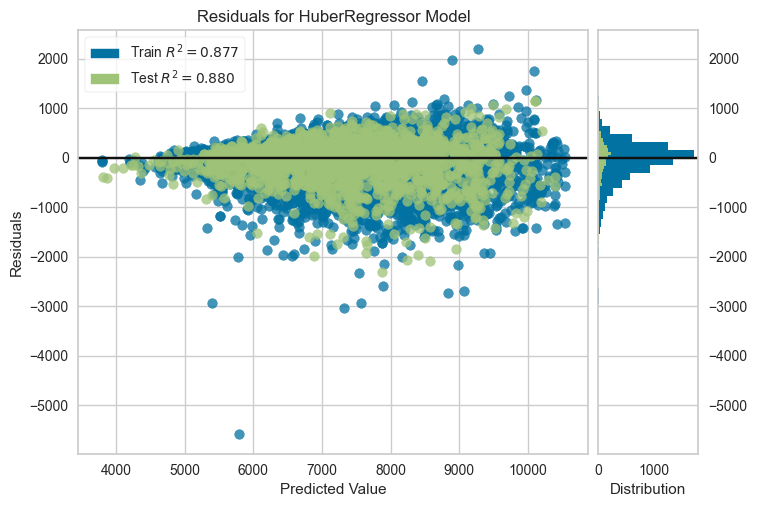

In [27]:
# Szybka wizualizacja: jak dobrze model przewiduje na zbiorze testowym.
# Wykres "residuals" (reszty) pokazuje różnicę między prawdziwym czasem
# a przewidywaniem modelu dla każdego zawodnika - im punkty bliżej linii
# zero (czyli mniejszy błąd), tym lepiej model sobie radzi.
plot_model(tuned_model, plot="residuals")


## 5. Zapis modelu - lokalnie i do Cloudflare R2

Zapisujemy model dwa razy:
- **lokalnie** w folderze `models/` (żeby np. aplikacja Streamlit mogła go szybko wczytać przy pierwszym uruchomieniu),
- **do R2** (żeby mieć kopię zapasową i móc pobrać go z dowolnego miejsca, np. z serwera Streamlit Cloud).

In [28]:
# "datetime" pozwala pobrać aktualną datę i godzinę - użyjemy jej do
# ponumerowania (wersjonowania) zapisywanego modelu.
import datetime

# Wersjonujemy model datą i godziną (np. "20260924_101530"), żeby przy
# kolejnych uruchomieniach notebooka NIE nadpisywać przypadkiem starszych,
# już działających wersji modelu.
version = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
model_name_local = f"../models/polmaraton_model_{version}"

# save_model() od PyCaret zapisuje model RAZEM z całym pipeline'em
# przetwarzania danych (kodowanie płci, normalizacja liczb itd.) - dzięki
# temu przy wczytywaniu modelu w aplikacji NIE musimy ręcznie powtarzać
# tych kroków, PyCaret zrobi to sam.
save_model(final_model, model_name_local)

# save_model() automatycznie dopisuje rozszerzenie ".pkl" na końcu nazwy pliku
local_pkl_path = model_name_local + ".pkl"
print("Model zapisany lokalnie:", local_pkl_path)


Transformation Pipeline and Model Successfully Saved
Model zapisany lokalnie: ../models/polmaraton_model_20260928_144815.pkl


In [29]:
# Wysyłamy ten sam plik .pkl do R2, do "podfolderu" models/ - pod nazwą
# zawierającą wersję (datę), żeby zachować historię wszystkich wytrenowanych modeli.
remote_key = f"models/polmaraton_model_{version}.pkl"
upload_file(local_pkl_path, BUCKET_NAME, remote_key)

# Dodatkowo NADPISUJEMY "najnowszą" wersję pod stałą, zawsze taką samą nazwą
# "models/latest.pkl" - dzięki temu aplikacja Streamlit zawsze wie DOKŁADNIE
# jaki plik pobrać, bez konieczności sprawdzania która wersja jest najnowsza.
upload_file(local_pkl_path, BUCKET_NAME, "models/latest.pkl")

print("Model wysłany do R2 jako:", remote_key, "oraz jako models/latest.pkl")


Model wysłany do R2 jako: models/polmaraton_model_20260928_144815.pkl oraz jako models/latest.pkl


## Podsumowanie

Ten notebook można uruchamiać ponownie za każdym razem, gdy pojawią się nowe dane treningowe
w R2 (np. wyniki z kolejnej edycji biegu). Każde uruchomienie tworzy nową, ozanczoną datą wersję
modelu, a aplikacja Streamlit zawsze będzie mogła pobrać najnowszą (`models/latest.pkl`).